<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Classification and KNN with NHL data

_Authors: Joseph Nelson (DC)_

---

Below you will practice KNN classification on a dataset of NHL statistics.

You will be predicting the `Rank` of a team from predictor variables of your choice.

In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# web location:
local_csv = 'data/NHL_Data_GA.csv'

### 1. Load the NHL data

In [3]:
# A:
nhl = pd.read_csv(local_csv)
nhl.head()

,Team,PTS,Rank,TOI,GF,GA,GF60,GA60,GF%,SF,...,FF%,CF,CA,CF60,CA60,CF%,Sh%,Sv%,PDO,PIM
0,Washington10,121,1,2001:52:00,115,73,3.45,2.19,61.2,1112,...,51.3,2138,1935,64.1,58.0,52.5,10.34,93.03,1034,1269
1,Vancouver11,117,1,2056:14:00,94,72,2.74,2.10,56.6,1143,...,53.1,2144,1870,62.6,54.6,53.4,8.22,93.16,1014,985
2,San Jose10,113,1,1929:54:00,90,68,2.80,2.11,57.0,1065,...,50.9,1985,1876,61.7,58.3,51.4,8.45,93.46,1019,1195
3,Chicago10,112,1,2020:23:00,104,83,3.09,2.46,55.6,1186,...,58.1,2093,1572,62.2,46.7,57.1,8.77,90.44,992,966
4,Vancouver12,111,1,2052:02:00,86,74,2.51,2.16,53.8,1078,...,51.0,2085,1880,61.0,55.0,52.6,7.98,93.36,1013,1049


### 2. Perform any required data cleaning. Do some EDA.

In [4]:
# A:
# Check for missing values and basic info
nhl.info()
print('---')
print('Missing values:\n', nhl.isna().sum())
print('---')
nhl.describe()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Team    90 non-null     str    
 1   PTS     90 non-null     int64  
 2   Rank    90 non-null     int64  
 3   TOI     90 non-null     str    
 4   GF      90 non-null     int64  
 5   GA      90 non-null     int64  
 6   GF60    90 non-null     float64
 7   GA60    90 non-null     float64
 8   GF%     90 non-null     float64
 9   SF      90 non-null     int64  
 10  SA      90 non-null     int64  
 11  SF60    90 non-null     float64
 12  SA60    90 non-null     float64
 13  SF%     90 non-null     float64
 14  FF      90 non-null     int64  
 15  FA      90 non-null     int64  
 16  FF60    90 non-null     float64
 17  FA60    90 non-null     float64
 18  FF%     90 non-null     float64
 19  CF      90 non-null     int64  
 20  CA      90 non-null     int64  
 21  CF60    90 non-null     float64
 22  CA60    90 non-

,PTS,Rank,GF,GA,GF60,GA60,GF%,SF,SA,SF60,...,FF%,CF,CA,CF60,CA60,CF%,Sh%,Sv%,PDO,PIM
count,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,...,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,91.977778,2.022222,83.288889,83.288889,2.442222,2.444000,49.981111,1068.333333,1068.333333,31.252222,...,49.966667,1973.466667,1973.466667,57.735556,57.798889,49.972222,7.814556,92.182556,999.988889,990.966667
std,12.524114,0.820767,10.376339,9.694484,0.325331,0.313522,4.644554,95.929047,75.514118,2.237637,...,2.797913,176.468299,154.148928,4.124476,4.291106,2.844313,0.866942,0.928621,12.292772,178.049321
min,62.000000,1.000000,57.000000,64.000000,1.700000,1.730000,38.000000,815.000000,868.000000,25.800000,...,43.100000,1565.000000,1572.000000,49.500000,46.700000,43.700000,5.900000,89.830000,978.000000,689.000000
25%,82.250000,1.000000,76.000000,75.500000,2.232500,2.202500,46.825000,1011.500000,1022.250000,29.550000,...,47.775000,1855.250000,1877.000000,54.275000,54.600000,47.925000,7.235000,91.555000,992.000000,881.250000
50%,92.500000,2.000000,84.000000,84.000000,2.400000,2.495000,49.700000,1072.000000,1072.000000,31.400000,...,50.050000,1981.500000,1961.000000,58.050000,58.350000,50.400000,7.730000,92.250000,1000.500000,960.000000
75%,102.000000,3.000000,90.000000,89.000000,2.600000,2.670000,53.625000,1143.000000,1125.750000,32.775000,...,51.775000,2112.750000,2077.250000,60.850000,60.400000,52.000000,8.270000,92.870000,1007.750000,1101.500000
max,121.000000,3.000000,115.000000,107.000000,3.450000,3.240000,61.200000,1311.000000,1245.000000,35.600000,...,58.100000,2341.000000,2332.000000,64.900000,67.500000,57.100000,10.340000,93.940000,1034.000000,1515.000000


### 3. Set up the `Rank` variable as your target. How many classes are there?

In [5]:
# A:
y = nhl['Rank']
print('Classes:', sorted(y.unique()))
print('Count per class:\n', y.value_counts().sort_index())
print('Number of classes:', y.nunique())

Classes: [np.int64(1), np.int64(2), np.int64(3)]
Count per class:
 Rank
1    29
2    30
3    31
Name: count, dtype: int64
Number of classes: 3


### 4. What is the baseline accuracy?

In [6]:
# A:
baseline = y.value_counts(normalize=True).max()
print(f'Baseline accuracy (always predict most frequent class): {baseline:.3f} ({baseline*100:.1f}%)')

Baseline accuracy (always predict most frequent class): 0.344 (34.4%)


### 5. Choose 4 features to be your predictor variables and set up your design matrix.

In [7]:
# A:
features = ['GF', 'GA', 'CF%', 'PDO']
X = nhl[features]
print('Selected features:', features)
X.head()

Selected features: ['GF', 'GA', 'CF%', 'PDO']


,GF,GA,CF%,PDO
0,115,73,52.5,1034
1,94,72,53.4,1014
2,90,68,51.4,1019
3,104,83,57.1,992
4,86,74,52.6,1013


### 6. Fit a `KNeighborsClassifier` with 1 neighbor using the target and predictors.

In [8]:
# A:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[1,2,3]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### 7. Evaluate the accuracy of your model.
- Is it better than baseline?
- Is it legitimate?

In [9]:
# A:
train_acc = knn.score(X, y)
print(f'Training accuracy (k=1, no split): {train_acc:.3f}')
print(f'Baseline accuracy: {baseline:.3f}')
print(f'Better than baseline? {train_acc > baseline}')
print('Is it legitimate? No! k=1 with no train-test split memorizes the data (100% accuracy is overfitting).')

Training accuracy (k=1, no split): 1.000
Baseline accuracy: 0.344
Better than baseline? True
Is it legitimate? No! k=1 with no train-test split memorizes the data (100% accuracy is overfitting).


### 8. Create a 50-50 train-test-split of your target and predictors. Refit the KNN and assess the accuracy.

In [10]:
# A:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

train_acc = knn.score(X_train, y_train)
test_acc = knn.score(X_test, y_test)
print(f'Training accuracy (50-50 split, k=1): {train_acc:.3f}')
print(f'Testing accuracy (50-50 split, k=1): {test_acc:.3f}')

Training accuracy (50-50 split, k=1): 1.000
Testing accuracy (50-50 split, k=1): 0.489


### 9. Evaluate the test accuracy of a KNN where K == number of rows in the training data.

In [11]:
# A:
k_max = len(X_train)
knn = KNeighborsClassifier(n_neighbors=k_max)
knn.fit(X_train, y_train)
test_acc = knn.score(X_test, y_test)
print(f'K = {k_max} (number of rows in training data)')
print(f'Testing accuracy (K=max): {test_acc:.3f}')
print('With K=max, the model predicts the most common class in training data for every test point.')

K = 45 (number of rows in training data)
Testing accuracy (K=max): 0.311
With K=max, the model predicts the most common class in training data for every test point.


### 10. Fit the KNN at values of K from 1 to the number of rows in the training data.
- Store the test accuracy in a list.
- Plot the test accuracy vs. the number of neighbors.

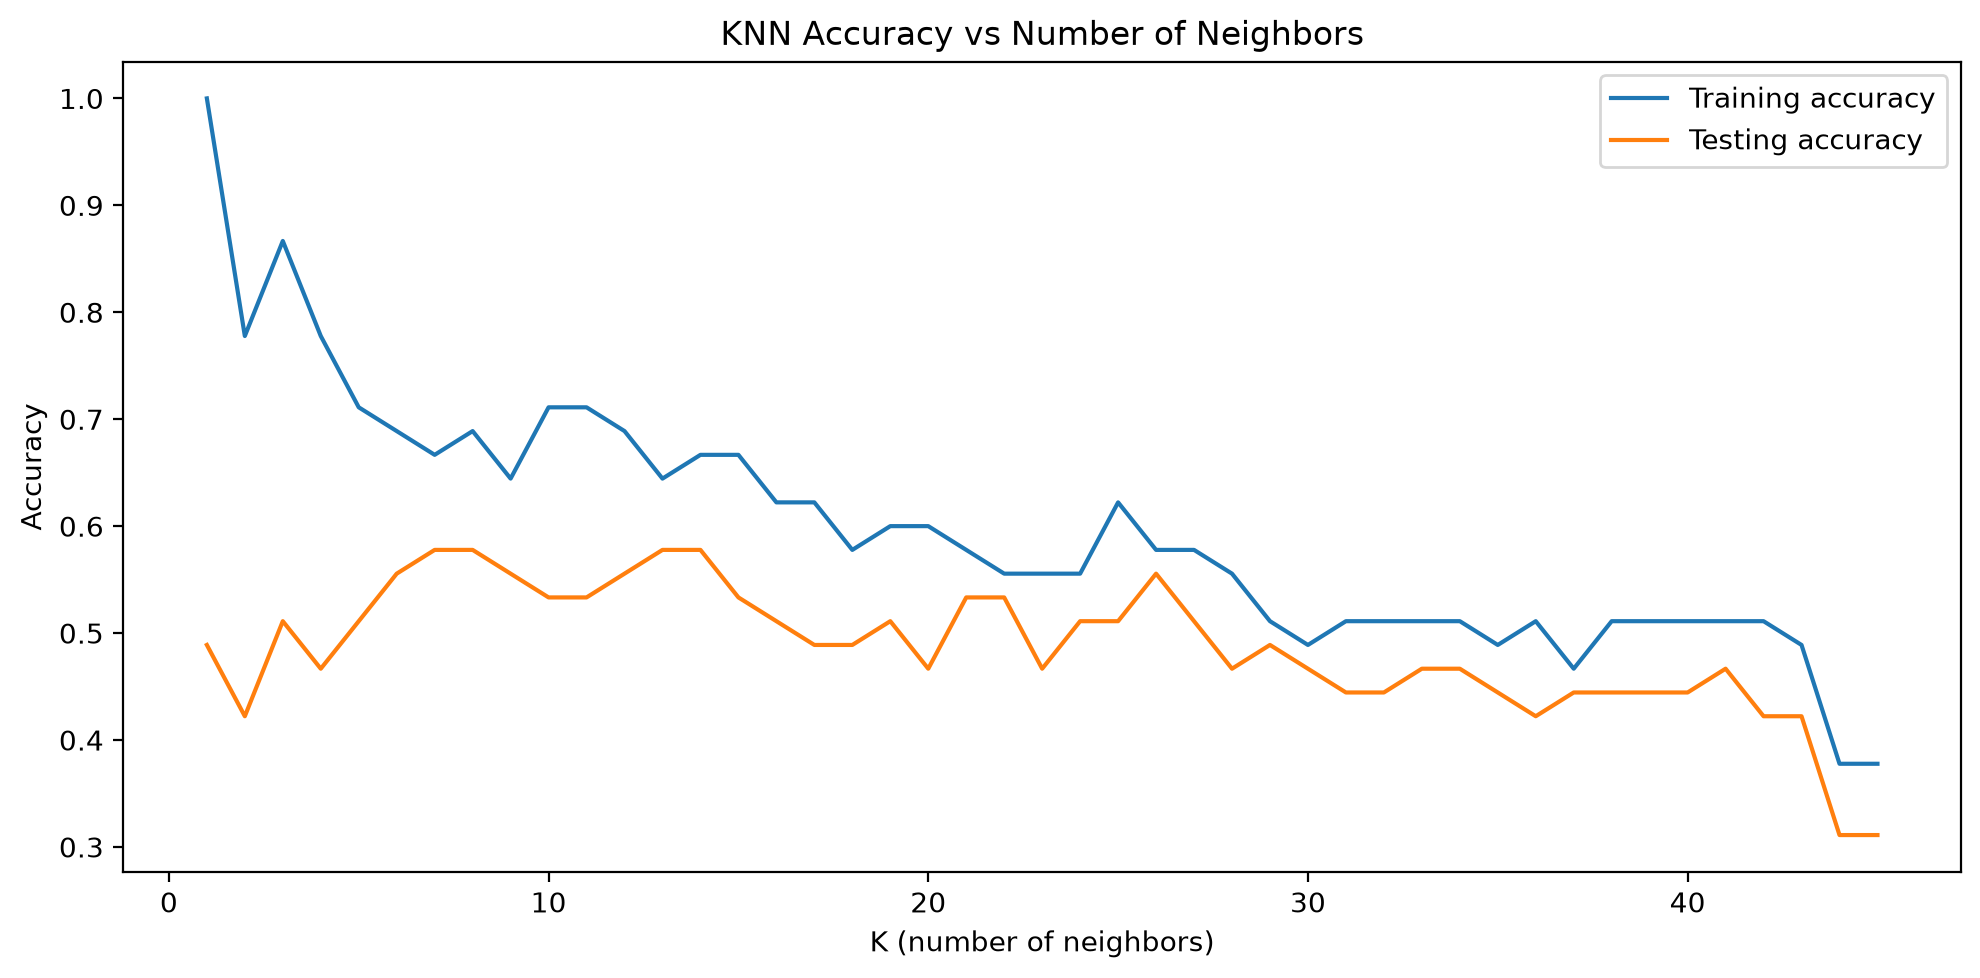

In [12]:
# A:
train_accs = []
test_accs = []
k_range = range(1, len(X_train) + 1)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accs.append(knn.score(X_train, y_train))
    test_accs.append(knn.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(k_range, train_accs, label='Training accuracy')
plt.plot(k_range, test_accs, label='Testing accuracy')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Accuracy')
plt.legend()
plt.title('KNN Accuracy vs Number of Neighbors')
plt.tight_layout()

### 11. Fit KNN across different values of K and plot the mean cross-validated accuracy with 5 folds.

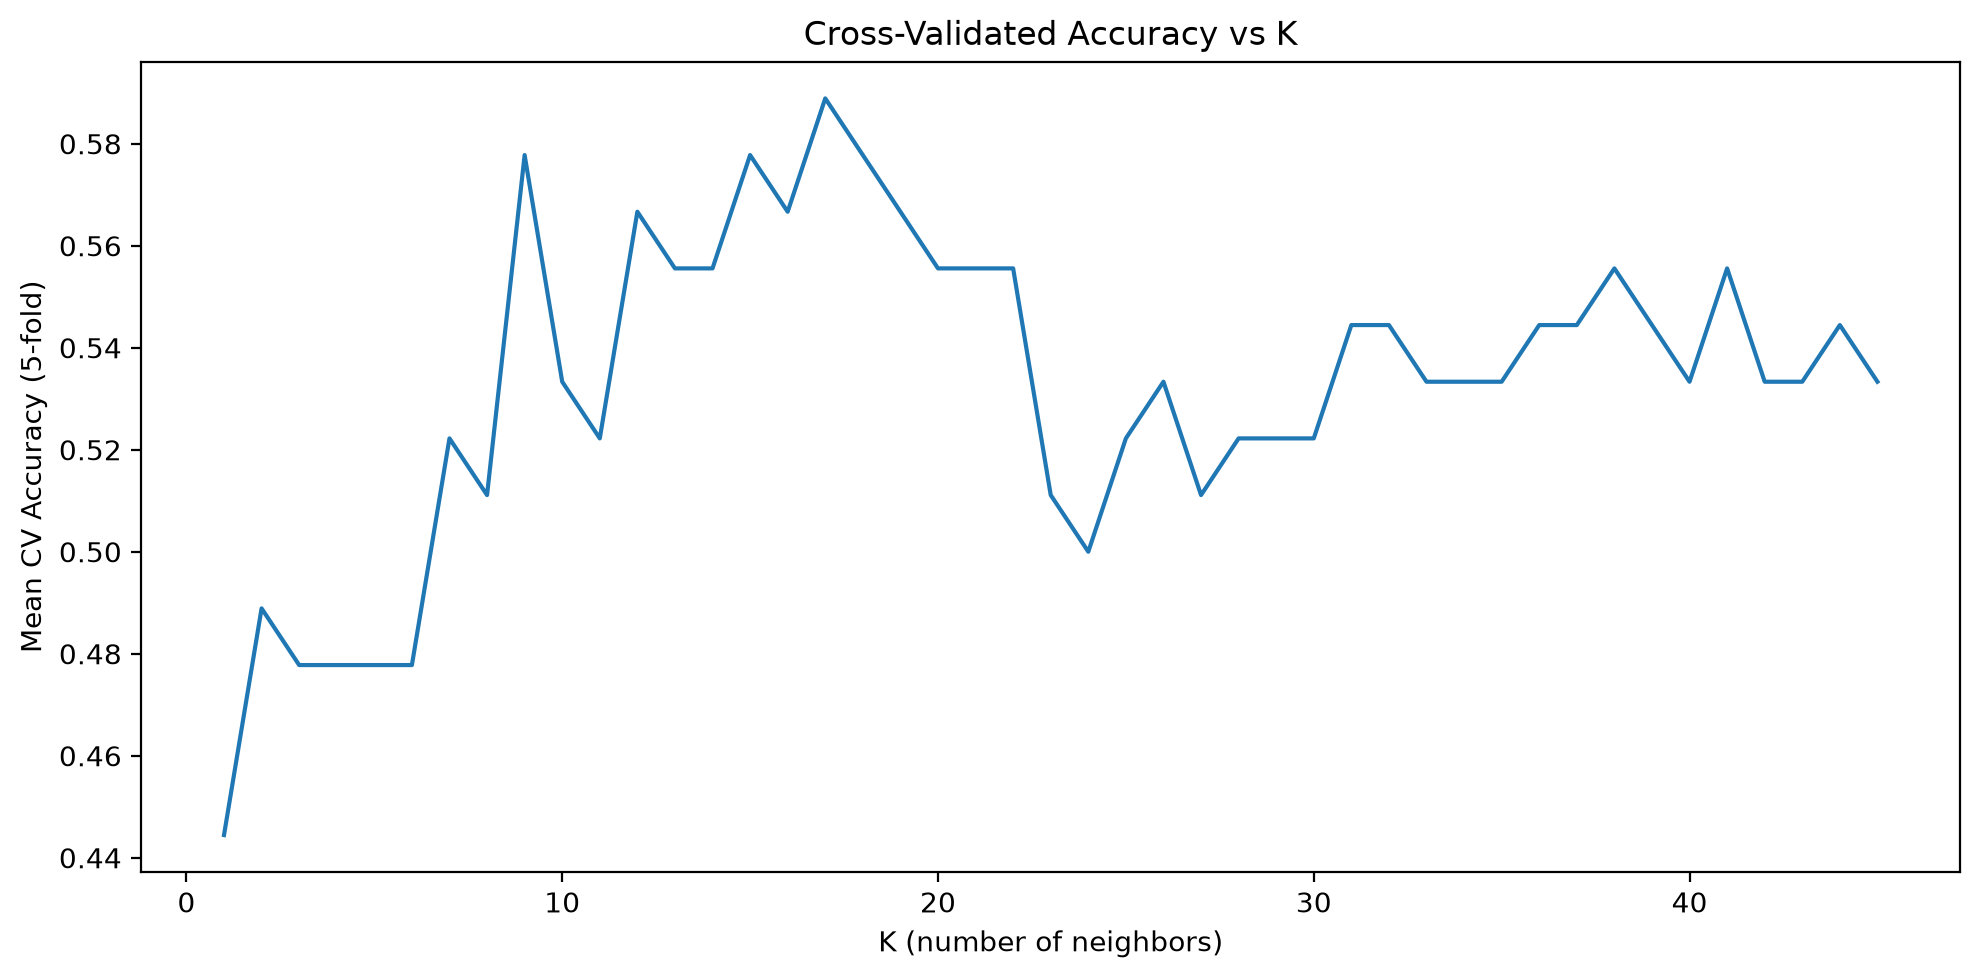

In [13]:
# A:
from sklearn.model_selection import cross_val_score

cv_accs = []
k_range = range(1, len(X_train) + 1)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5)
    cv_accs.append(scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(k_range, cv_accs)
plt.xlabel('K (number of neighbors)')
plt.ylabel('Mean CV Accuracy (5-fold)')
plt.title('Cross-Validated Accuracy vs K')
plt.tight_layout()

### 12. Standardize the predictor matrix and cross-validate across the different K.
- Plot the standardized mean cross-validated accuracy against the unstandardized. Which is better?
- Why?

Best CV accuracy (unstandardized): 0.589 at K=17
Best CV accuracy (standardized):   0.633 at K=33

Standardization typically improves KNN because it ensures all features contribute equally to distance calculations.


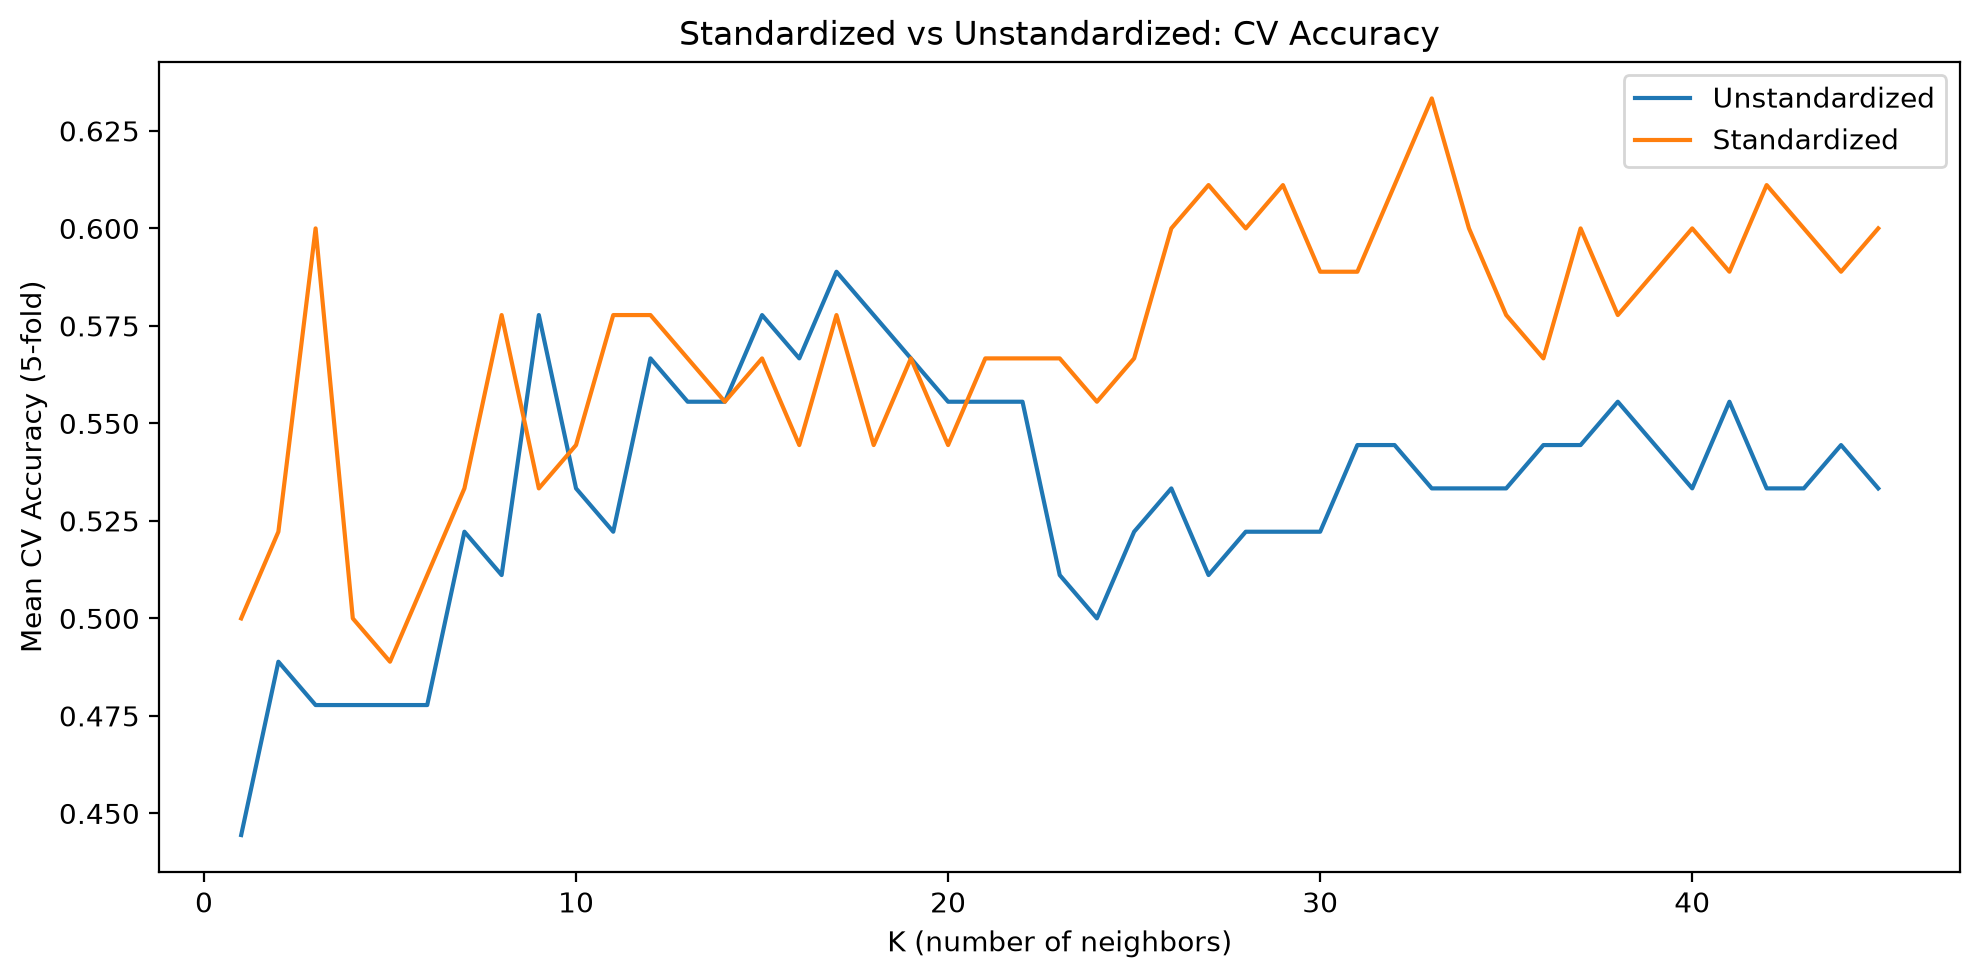

In [14]:
# A:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cv_accs_scaled = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5)
    cv_accs_scaled.append(scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(k_range, cv_accs, label='Unstandardized')
plt.plot(k_range, cv_accs_scaled, label='Standardized')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Mean CV Accuracy (5-fold)')
plt.legend()
plt.title('Standardized vs Unstandardized: CV Accuracy')
plt.tight_layout()

print(f'Best CV accuracy (unstandardized): {max(cv_accs):.3f} at K={cv_accs.index(max(cv_accs)) + 1}')
print(f'Best CV accuracy (standardized):   {max(cv_accs_scaled):.3f} at K={cv_accs_scaled.index(max(cv_accs_scaled)) + 1}')
print('\nStandardization typically improves KNN because it ensures all features contribute equally to distance calculations.')

## What was the best 'k'?

Using `GridSearch` & `Pipeline` find the best `k` for the KNN model

In [15]:
# GridSearch & Pipeline to find best K
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {'knn__n_neighbors': range(1, len(X) + 1)}
gs = GridSearchCV(pipe, param_grid, cv=5)
gs.fit(X, y)

print(f'Best K: {gs.best_params_["knn__n_neighbors"]}')
print(f'Best CV accuracy: {gs.best_score_:.3f}')

/home/ultori/jupyter-env/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/ultori/jupyter-env/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ultori/jupyter-env/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 531, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ultori/jupyter-env/lib/python3.12/site-packages/sklearn/pipeline.py", line 1202, in score
    return self.steps[-1][1].score(Xt, y, **score_params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ultori/jupyter-env/lib/python3.12/site-packages/sklearn/neighbor

Best K: 43
Best CV accuracy: 0.644


/home/ultori/jupyter-env/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/ultori/jupyter-env/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ultori/jupyter-env/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 531, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ultori/jupyter-env/lib/python3.12/site-packages/sklearn/pipeline.py", line 1202, in score
    return self.steps[-1][1].score(Xt, y, **score_params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ultori/jupyter-env/lib/python3.12/site-packages/sklearn/neighbor

In [ ]:
# Visualize grid search results
results = pd.DataFrame(gs.cv_results_)
plt.figure(figsize=(10, 5))
plt.plot(results['param_knn__n_neighbors'], results['mean_test_score'])
plt.xlabel('K (number of neighbors)')
plt.ylabel('Mean CV Accuracy')
plt.title('GridSearch CV Results — Pipeline with StandardScaler')
plt.axvline(gs.best_params_['knn__n_neighbors'], color='r', linestyle='--', alpha=0.5, label=f"Best K = {gs.best_params_['knn__n_neighbors']}")
plt.legend()
plt.tight_layout()